# Data Exploration with Droughts

Necessary Imports

In [56]:
import numpy as np 
!pip install statsmodels
import statsmodels.api as sm
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline
import matplotlib.dates as mdates 


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [57]:
county = "Fresno"
df = pd.read_csv(f'../../data/{county.lower()}_agg_drought.csv')

In [58]:
df

,YEAR_MONTH,VFRate,FIRE_Acres_Burned,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,POUNDS_PRODUCT_APPLIED,Avg_Monthly_DSCI
0,2008-10,6.156349,163.91,0.18,0.0,3.667742,87.825806,70.0,53.0,0,23.056051,782.3835,515.4225
1,2008-11,3.407979,17.30,1.49,0.0,3.106667,74.490000,95.5,38.5,0,0.519323,515.6780,501.6900
2,2008-12,6.486154,0.00,1.19,0.0,3.306452,79.312903,94.0,18.5,0,0.000000,238.7675,501.5300
3,2009-01,6.619800,1.00,1.25,0.0,2.587097,62.019355,102.0,33.0,0,24.630400,395.1969,502.2950
4,2009-02,5.751629,28.00,2.33,0.0,3.928571,94.096429,51.5,13.0,0,71.542885,375.1287,501.9950
...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,2015-08,2.569621,28.06,0.00,0.0,4.900000,117.664516,63.0,44.0,0,737.718551,1423.6719,1500.0000
83,2015-09,2.775191,210.76,0.06,0.0,4.046667,97.216667,62.0,52.0,0,544.970947,2064.4267,1500.0000
84,2015-10,5.344812,16.99,0.41,0.0,3.503226,84.058065,63.0,38.0,0,181.244457,1673.8602,1500.0000
85,2015-11,2.569621,30.46,2.13,0.0,3.116667,74.736667,75.0,26.5,0,263.108466,1307.2290,1500.0000


In [59]:
df = df.rename(columns={'POUNDS_PRODUCT_APPLIED': 'RODENTICIDE_Total'})
print(df.head())

  YEAR_MONTH    VFRate  FIRE_Acres_Burned  PRECIP  WIND_EventCount  \
0    2008-10  6.156349             163.91    0.18              0.0   
1    2008-11  3.407979              17.30    1.49              0.0   
2    2008-12  6.486154               0.00    1.19              0.0   
3    2009-01  6.619800               1.00    1.25              0.0   
4    2009-02  5.751629              28.00    2.33              0.0   

   WIND_AvgMPH  WIND_RunMiles  AQI_PM25  AQI_PM10  EARTHQUAKE_Total  \
0     3.667742      87.825806      70.0      53.0                 0   
1     3.106667      74.490000      95.5      38.5                 0   
2     3.306452      79.312903      94.0      18.5                 0   
3     2.587097      62.019355     102.0      33.0                 0   
4     3.928571      94.096429      51.5      13.0                 0   

   PESTICIDE_Total  RODENTICIDE_Total  Avg_Monthly_DSCI  
0        23.056051           782.3835          515.4225  
1         0.519323           515.678

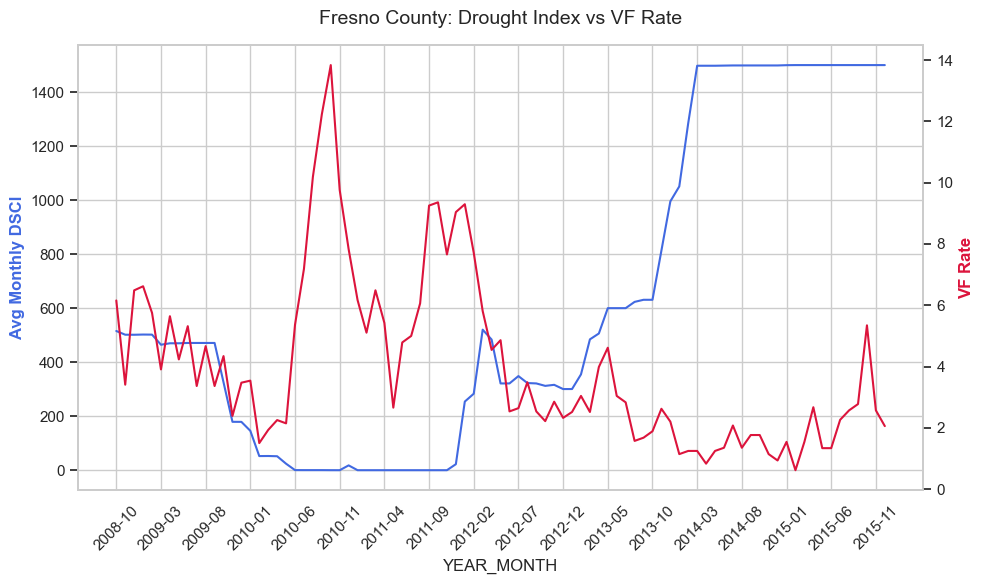

In [60]:
sns.set_theme(style="whitegrid") 

fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(data=df, x='YEAR_MONTH', y='Avg_Monthly_DSCI', ax=ax1, color='royalblue')
sns.lineplot(data=df, x='YEAR_MONTH', y='VFRate', ax=ax2, color='crimson')

ax1.tick_params(axis='x', rotation=45) 
current_ticks = ax1.get_xticks()
ax1.set_xticks(current_ticks[::5])

ax1.set_title(f"{county} County: Drought Index vs VF Rate", fontsize=14, pad=15)
ax1.set_ylabel("Avg Monthly DSCI", color='royalblue', fontweight='bold')
ax2.set_ylabel("VF Rate", color='crimson', fontweight='bold')
ax2.grid(False)
plt.tight_layout()
plt.show()


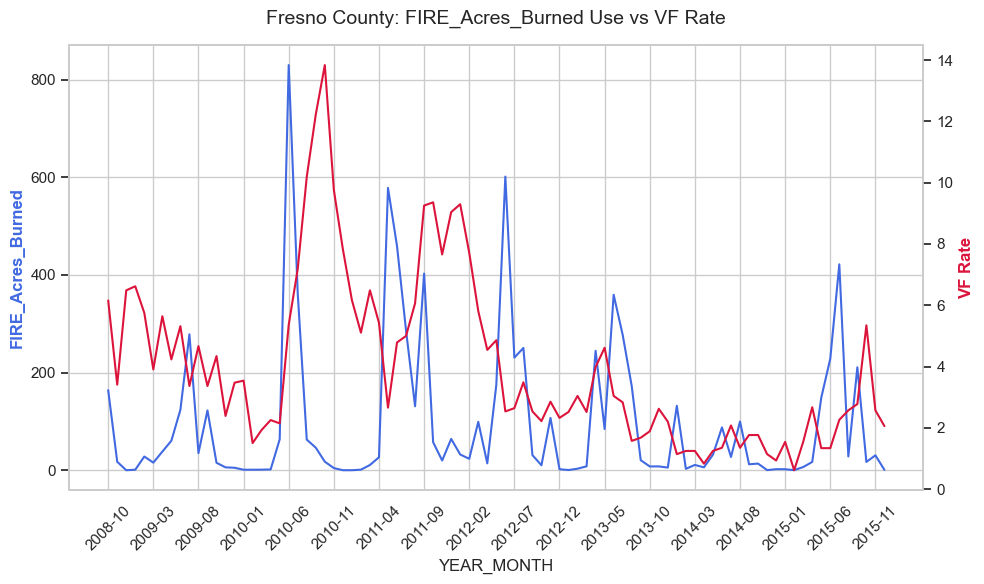

In [61]:
sns.set_theme(style="whitegrid") 
tgt_variable = "FIRE_Acres_Burned"
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(data=df, x='YEAR_MONTH', y=f"{tgt_variable}", ax=ax1, color='royalblue')
sns.lineplot(data=df, x='YEAR_MONTH', y='VFRate', ax=ax2, color='crimson')

ax1.tick_params(axis='x', rotation=45) 
current_ticks = ax1.get_xticks()
ax1.set_xticks(current_ticks[::5])

ax1.set_title(f"{county} County: {tgt_variable} Use vs VF Rate", fontsize=14, pad=15)
ax1.set_ylabel(f"{tgt_variable}", color='royalblue', fontweight='bold')
ax2.set_ylabel("VF Rate", color='crimson', fontweight='bold')
ax2.grid(False)
plt.tight_layout()
plt.show()


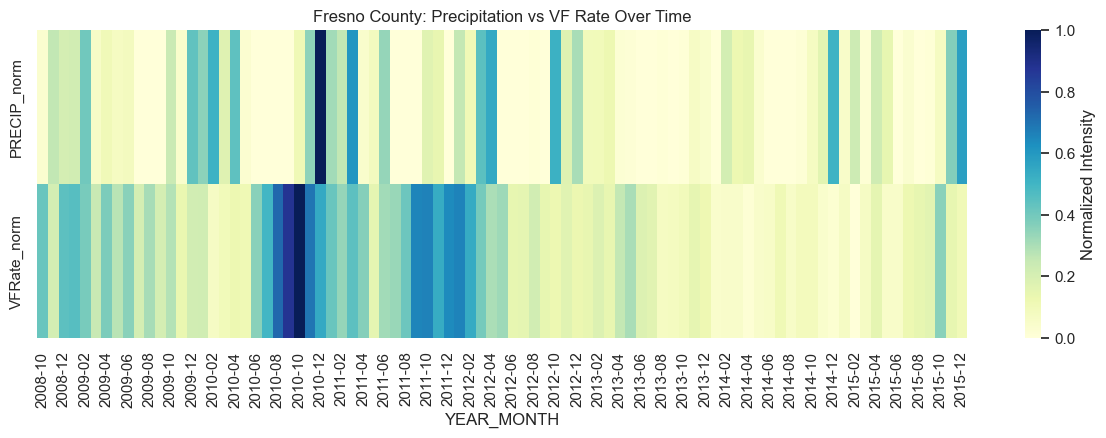

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data: normalize the scales so they share a 0-1 range for the colors
df_norm = df.copy()
df_norm['PRECIP_norm'] = (df['PRECIP'] - df['PRECIP'].min()) / (df['PRECIP'].max() - df['PRECIP'].min())
df_norm['VFRate_norm'] = (df['VFRate'] - df['VFRate'].min()) / (df['VFRate'].max() - df['VFRate'].min())

# Transpose for heatmap format
heat_df = df_norm.set_index('YEAR_MONTH')[['PRECIP_norm', 'VFRate_norm']].T

plt.figure(figsize=(15, 4))
sns.heatmap(heat_df, cmap="YlGnBu", cbar_kws={'label': 'Normalized Intensity'})
plt.title(f"{county} County: Precipitation vs VF Rate Over Time")
plt.show()

In [63]:
df.describe()

,VFRate,FIRE_Acres_Burned,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,RODENTICIDE_Total,Avg_Monthly_DSCI
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,4.022209,99.292529,0.853103,0.264368,4.303793,103.301826,67.442529,32.264368,0.183908,1617.739402,2250.341285,614.101420
std,2.760574,156.268683,1.091071,0.599608,1.021575,24.507755,19.790975,12.298099,0.619991,2098.613819,2751.119050,575.763302
min,0.616709,0.000000,0.000000,0.000000,2.527778,60.838889,42.000000,11.000000,0.000000,0.000000,238.767500,0.000000
25%,2.065922,5.860000,0.020000,0.000000,3.404090,81.713571,55.000000,24.000000,0.000000,78.141883,953.767800,52.454000
50%,3.041012,27.100000,0.410000,0.000000,4.306452,103.312903,61.500000,29.000000,0.000000,737.626764,1495.257600,471.160000
75%,5.393994,127.310000,1.310000,0.000000,4.967419,119.019677,75.500000,41.000000,0.000000,2519.029075,2285.586650,1391.256250
max,13.838202,829.640000,5.740000,3.000000,6.720000,161.153333,140.000000,66.000000,5.000000,10167.267623,18831.611300,1500.000000


array([[<Axes: title={'center': 'VFRate'}>,
        <Axes: title={'center': 'FIRE_Acres_Burned'}>,
        <Axes: title={'center': 'PRECIP'}>],
       [<Axes: title={'center': 'WIND_EventCount'}>,
        <Axes: title={'center': 'WIND_AvgMPH'}>,
        <Axes: title={'center': 'WIND_RunMiles'}>],
       [<Axes: title={'center': 'AQI_PM25'}>,
        <Axes: title={'center': 'AQI_PM10'}>,
        <Axes: title={'center': 'EARTHQUAKE_Total'}>],
       [<Axes: title={'center': 'PESTICIDE_Total'}>,
        <Axes: title={'center': 'RODENTICIDE_Total'}>,
        <Axes: title={'center': 'Avg_Monthly_DSCI'}>]], dtype=object)

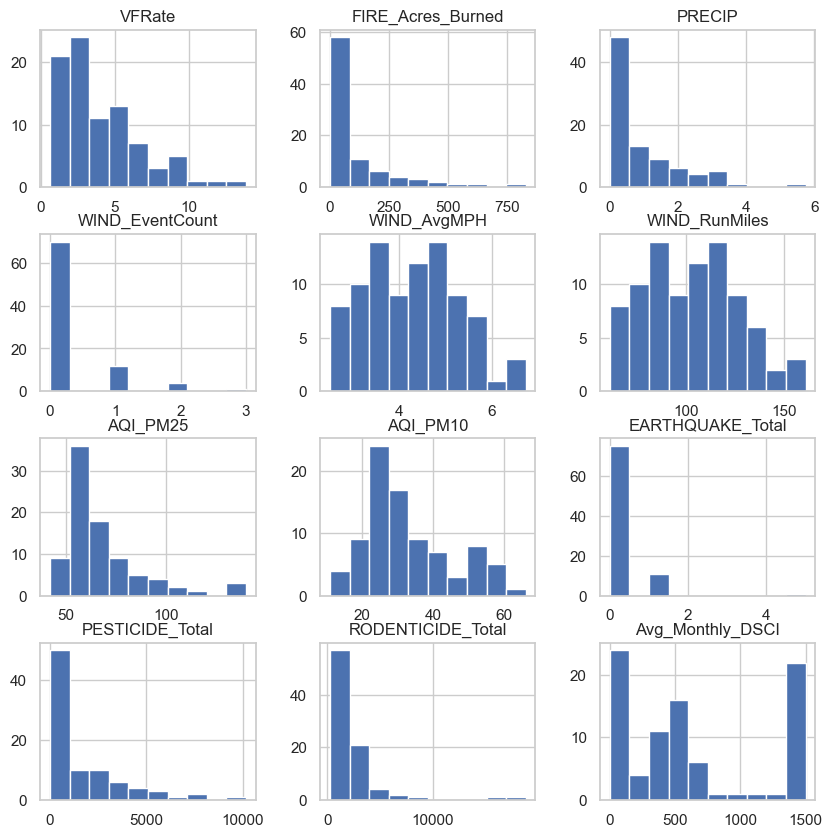

In [64]:
df.hist(figsize=(10,10))

Observations:
- Pesticide total is definitely right-skewed with some outliers
- Similarly with Pounds of Product Applied (Need to rename to Rodenticide)
- Earthquake is kind of weird, so low
- Wind event count needs some feature engineering
- AQI PM_25 maybe? Idk about AQI_PM10... almost normalish
- Fire Acres Burned and Precip are definitely right-skewed

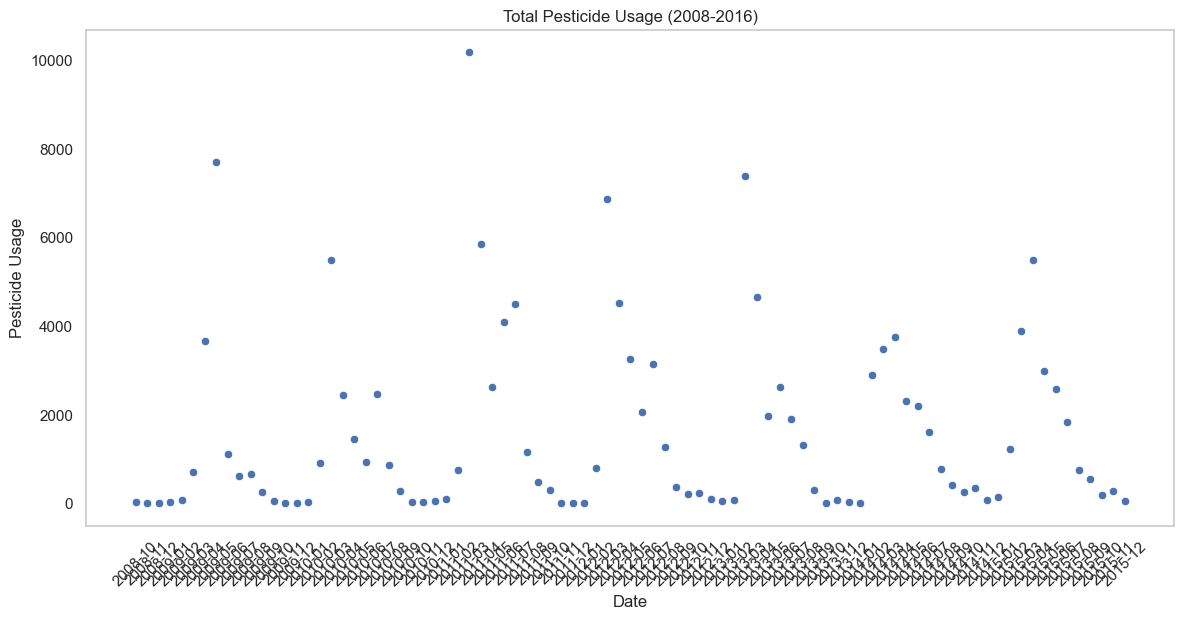

In [65]:
plt.figure(figsize=(12,6))
sns.scatterplot(df, x = "YEAR_MONTH", y = "PESTICIDE_Total")
plt.title("Total Pesticide Usage (2008-2016)")
plt.xlabel("Date")
plt.ylabel("Pesticide Usage")
plt.tight_layout()
plt.grid(False)
plt.xticks(rotation=45)
plt.show()

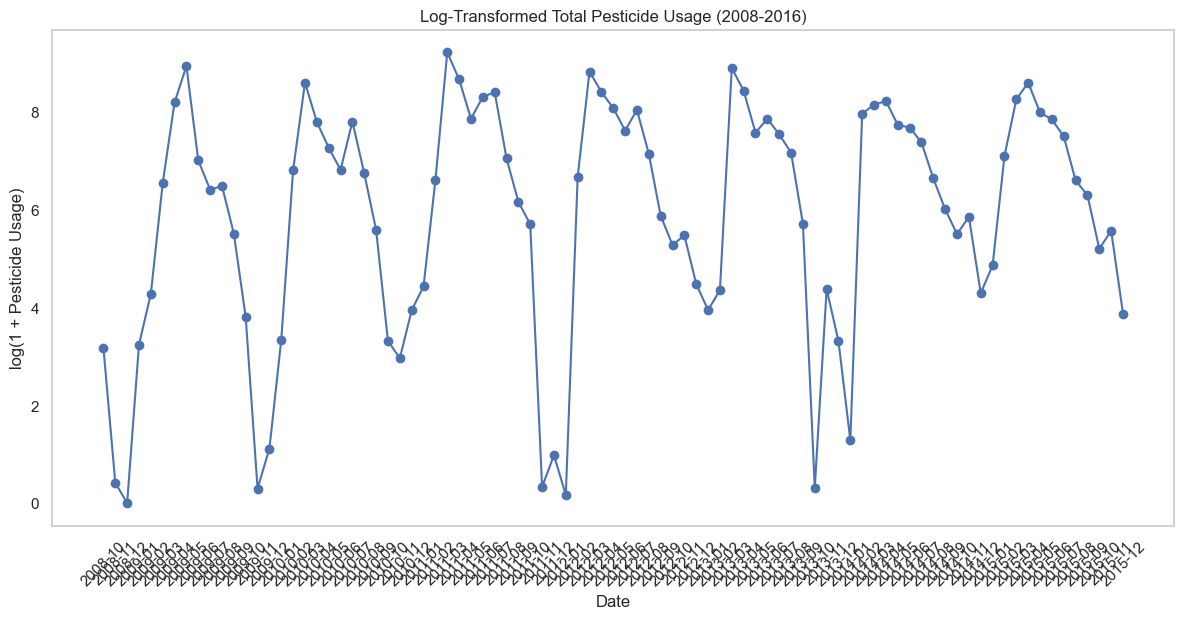

In [66]:
plt.figure(figsize=(12,6))
plt.plot(df["YEAR_MONTH"], np.log1p(df["PESTICIDE_Total"]), marker="o", linestyle="-")
plt.title("Log-Transformed Total Pesticide Usage (2008-2016)")
plt.xlabel("Date")
plt.ylabel("log(1 + Pesticide Usage)")
plt.tight_layout()
plt.grid(False)
plt.xticks(rotation=45)
plt.show()


Text(0.5, 1.0, 'Histogram of log(1+Pesticide Usage)')

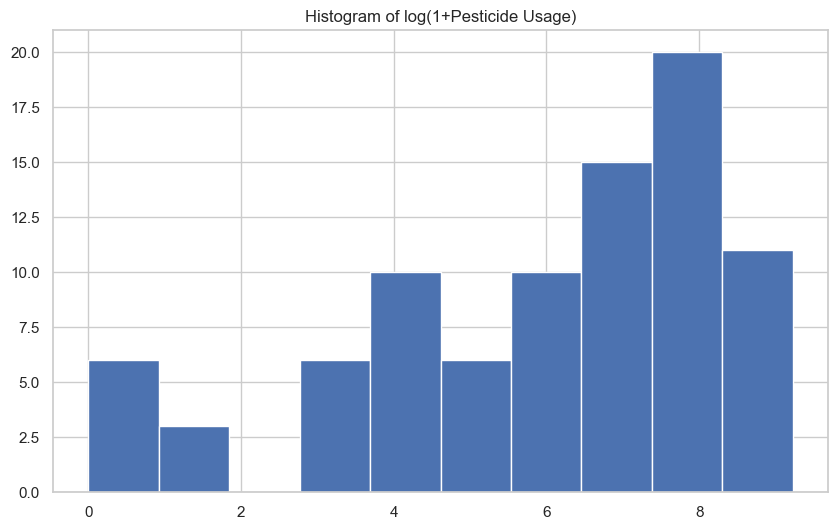

In [67]:
plt.figure(figsize=(10,6))
plt.hist(np.log1p(df["PESTICIDE_Total"]))
plt.title("Histogram of log(1+Pesticide Usage)")

Normality check for log(1+Rodenticide) has a p-value = 0.08165820353496792


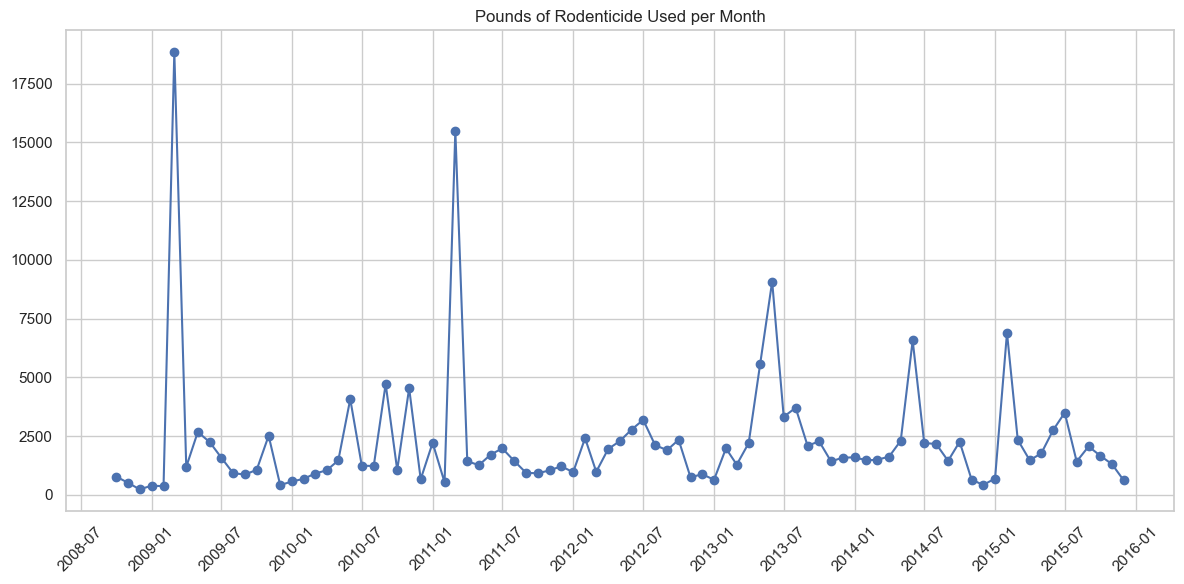

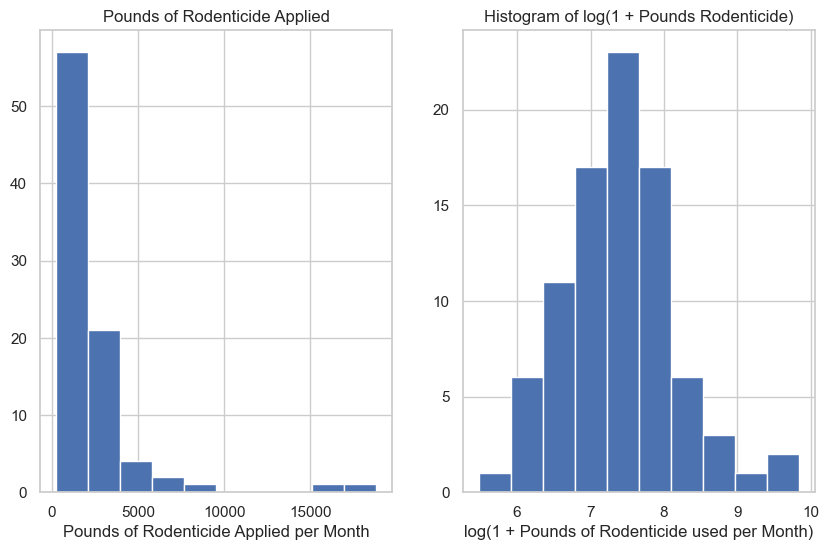

In [68]:
df["YEAR_MONTH"] = pd.to_datetime(df["YEAR_MONTH"])

fig, ax = plt.subplots(figsize=(12,6))
plt.plot(df["YEAR_MONTH"], df["RODENTICIDE_Total"], marker="o", linestyle="-")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.grid(True)
plt.title("Pounds of Rodenticide Used per Month")
plt.xticks(rotation=45)
plt.tight_layout()



plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.hist(df["RODENTICIDE_Total"])
plt.title("Pounds of Rodenticide Applied")
plt.xlabel("Pounds of Rodenticide Applied per Month")
plt.subplot(1,2,2)
plt.hist(np.log1p(df["RODENTICIDE_Total"]))
plt.title("Histogram of log(1 + Pounds Rodenticide)")
plt.xlabel("log(1 + Pounds of Rodenticide used per Month)")

from scipy.stats import shapiro 
stats, pval = shapiro(np.log1p(df["RODENTICIDE_Total"]))
print(f"Normality check for log(1+Rodenticide) has a p-value = {pval}")



Text(0, 0.5, 'log(1+ lbs Rodenticide) per Month')

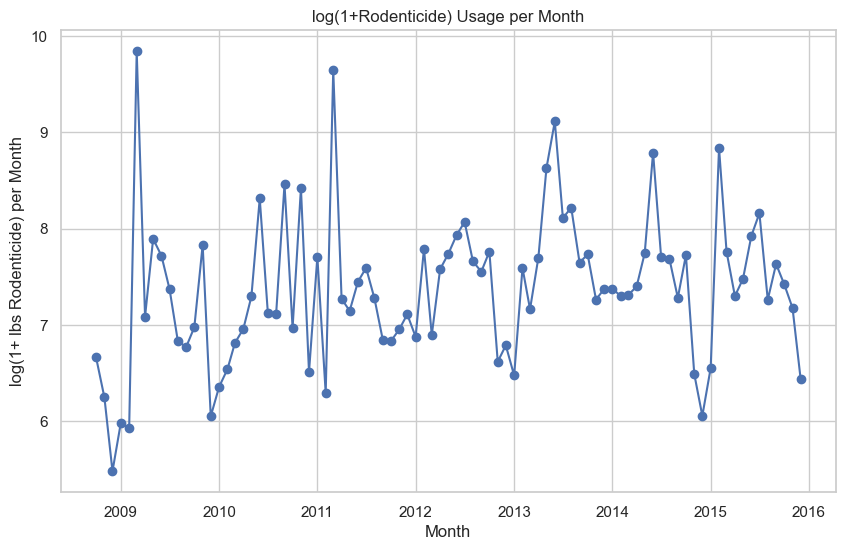

In [69]:
plt.figure(figsize=(10,6))
plt.plot(df["YEAR_MONTH"], np.log1p(df["RODENTICIDE_Total"]), marker="o", linestyle="-")
plt.title("log(1+Rodenticide) Usage per Month")
plt.xlabel("Month")
plt.ylabel("log(1+ lbs Rodenticide) per Month")

# Observations and Next Steps:

## Observations

In doing this data exploration, I have noticed that we have some continuous variables that are heavily right-skewed. This means we have a lot of counts clustered aroung the same values but a set of large outliers that create a fat right tail. In order to modify this behavior, we can use the log tranform from `np.log1p(data)`. As seen above, this made the Rodenticide normal (Shapiro-Wilk test p = .08). 

## Next Steps

Next steps are to check to see what other right skewed data is useful to transform and if its normal after the log transformation. Once this is done, I will create a new dataframe and data files with these values and see how the LSTM performs. 

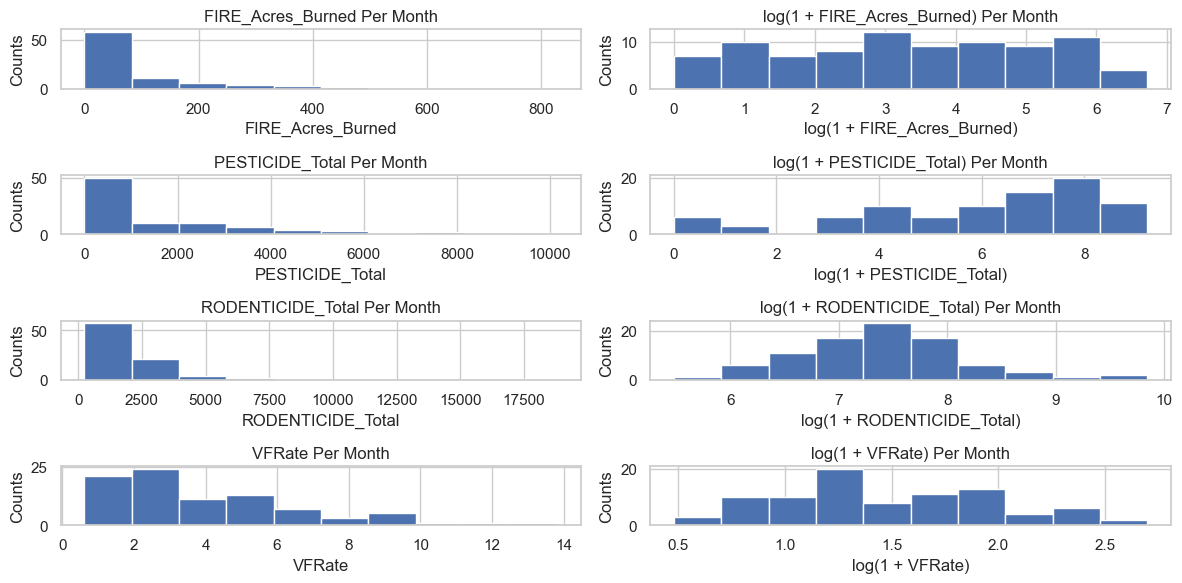

In [70]:
# Other Data to try out:
# Pesticide Data, Fire, Precip 
lbls_in_question = ["FIRE_Acres_Burned", "PESTICIDE_Total", "RODENTICIDE_Total",  "VFRate"]
plt.figure(figsize=(12,6))
lblIdx = 0;
for ii in range(1, 9):
  plt.subplot(4,2,ii)
  if ii % 2 == 0:
    plt.hist(np.log1p(df[lbls_in_question[lblIdx]]))
    plt.title(f"log(1 + {lbls_in_question[lblIdx]}) Per Month")
    plt.xlabel(f"log(1 + {lbls_in_question[lblIdx]})")
    plt.ylabel("Counts")
    lblIdx = lblIdx + 1
  else:
    plt.hist(df[lbls_in_question[lblIdx]])
    plt.title(f"{lbls_in_question[lblIdx]} Per Month")
    plt.xlabel(f"{lbls_in_question[lblIdx]}")
    plt.ylabel("Counts")

plt.tight_layout()

In [80]:
stats, pval = shapiro(np.log1p(df["VFRate"]))
print(f"Normality check for log(1+VFRate) has a p-value = {pval}")

lbls_in_question = ["FIRE_Acres_Burned", "PESTICIDE_Total", "RODENTICIDE_Total", "VFRate"]

for feat in lbls_in_question:
  _, pval = shapiro(np.log1p(df[feat]))
  print(f"Shapiro-Wilks test for {feat} : {pval}")

# other transform
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method="yeo-johnson", standardize=True)
# _, pval = shapiro(np.cbrt(df["PESTICIDE_Total"]))
vals = pt.fit_transform(df["PESTICIDE_Total"].values.reshape(-1,1))
_, pval = shapiro(vals.flatten())
print(f"yeo-johnson transform shapiro-wilks pval for PESTICIDE_Total: {pval}")
# print(f"Shapiro-Wilks for cbrt(PESTICIDE_Total): {pval}")
print(f"YJ lambda: {pt.lambdas_[0]:.4f}")

Normality check for log(1+VFRate) has a p-value = 0.10625253348721159
Shapiro-Wilks test for FIRE_Acres_Burned : 0.020754381953641717
Shapiro-Wilks test for PESTICIDE_Total : 6.4199882750248455e-06
Shapiro-Wilks test for RODENTICIDE_Total : 0.08165820353496792
Shapiro-Wilks test for VFRate : 0.10625253348721159
yeo-johnson transform shapiro-wilks pval for PESTICIDE_Total: 0.017544977464096605
YJ lambda: 0.1974


In [72]:
_, pvalDSCI = shapiro(df["Avg_Monthly_DSCI"])
_, pvalLogDSCI = shapiro(np.log1p(df["Avg_Monthly_DSCI"]))
print(f"original DSCI normality pval: {pvalDSCI}")
print(f"log transform DSCI normality pval: {pvalLogDSCI}")

original DSCI normality pval: 3.7014923591887132e-09
log transform DSCI normality pval: 4.161762919452797e-11


Text(0.5, 1.0, 'Fresno:QQ Plot for PESTICIDE_Total with Yeo-Johnson Transformation')

<Figure size 1000x600 with 0 Axes>

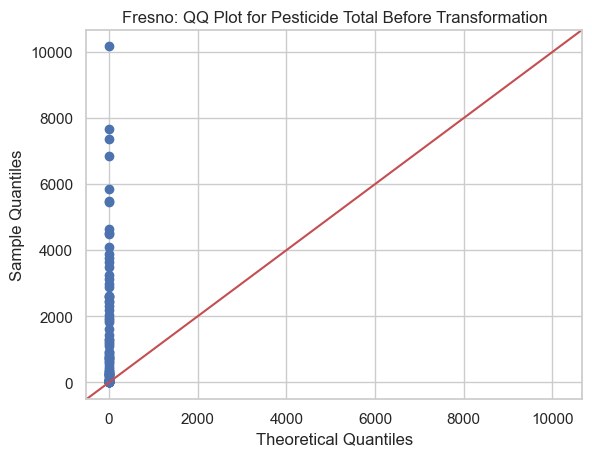

<Figure size 1000x600 with 0 Axes>

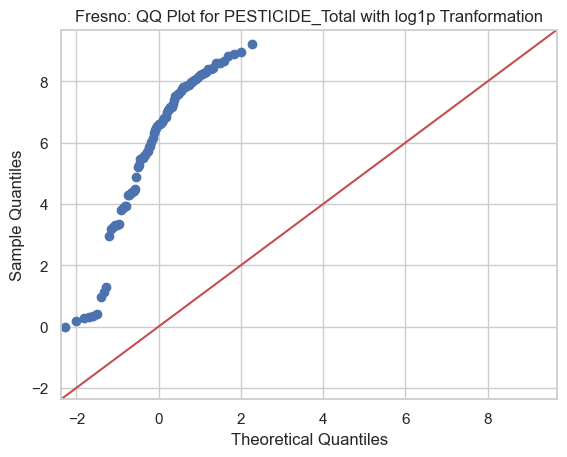

<Figure size 1000x600 with 0 Axes>

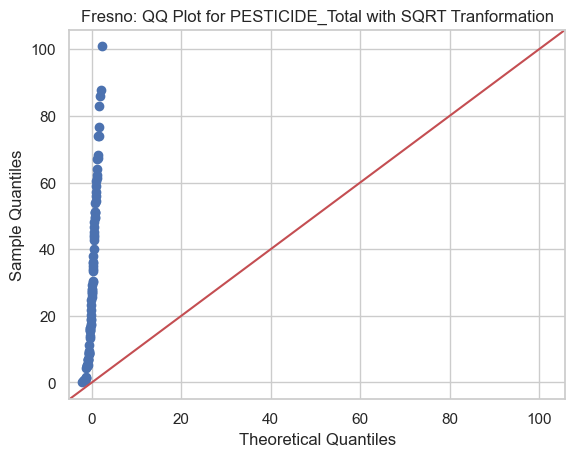

<Figure size 1000x600 with 0 Axes>

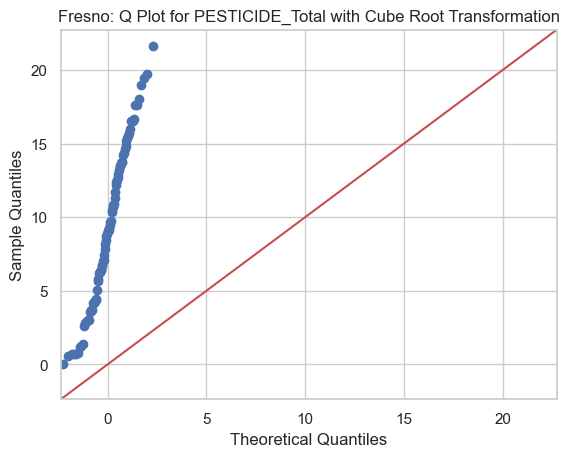

<Figure size 1000x600 with 0 Axes>

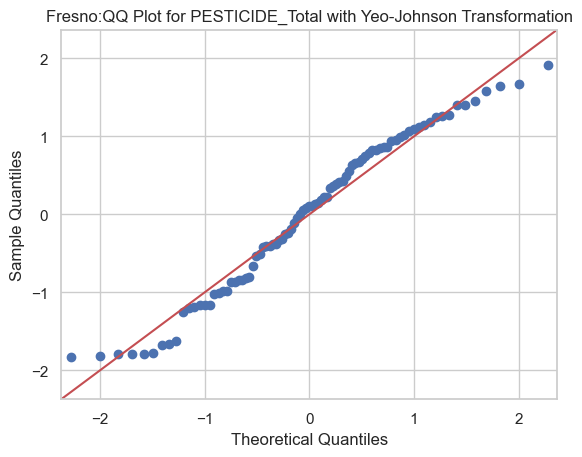

In [73]:
# QQ plots
plt.figure(figsize=(10,6))
sm.qqplot(df["PESTICIDE_Total"], line="45")
plt.title(f"{county}: QQ Plot for Pesticide Total Before Transformation")

plt.figure(figsize=(10,6))
sm.qqplot(np.log1p(df["PESTICIDE_Total"]), line='45')
plt.title(f"{county}: QQ Plot for PESTICIDE_Total with log1p Tranformation")

plt.figure(figsize=(10,6))
sm.qqplot(np.sqrt(df["PESTICIDE_Total"]), line='45')
plt.title(f"{county}: QQ Plot for PESTICIDE_Total with SQRT Tranformation")

plt.figure(figsize=(10,6))
sm.qqplot(np.cbrt(df["PESTICIDE_Total"]), line='45')
plt.title(f"{county}: Q Plot for PESTICIDE_Total with Cube Root Transformation")

plt.figure(figsize=(10,6))
sm.qqplot(vals.flatten(), line='45')
plt.title(f"{county}:QQ Plot for PESTICIDE_Total with Yeo-Johnson Transformation")

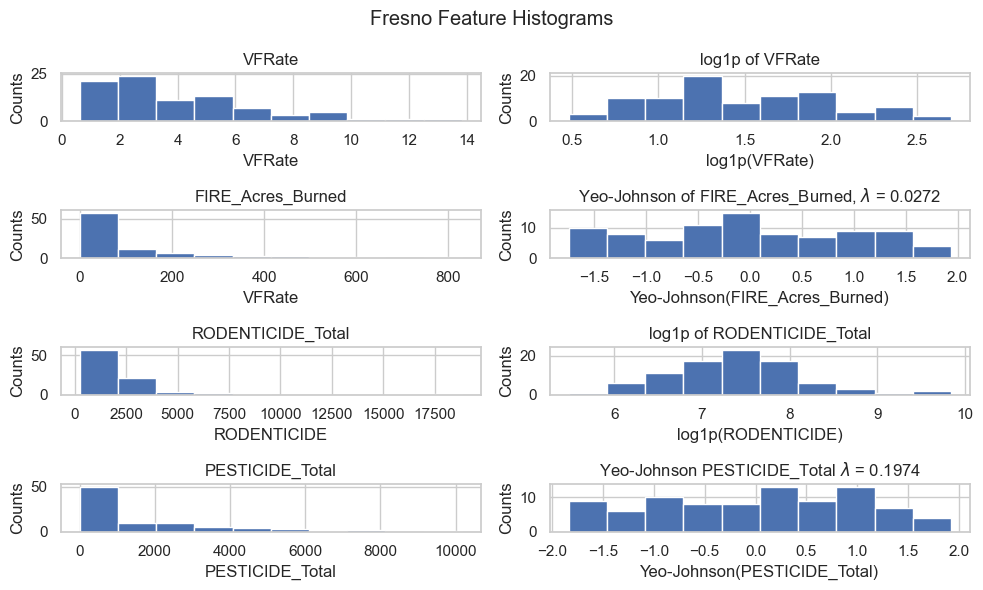

In [81]:
pt2 = PowerTransformer(method='yeo-johnson', standardize=True)
newdata = pt2.fit_transform(df["FIRE_Acres_Burned"].values.reshape(-1,1))

plt.figure(figsize=(10,6))
plt.subplot(4,2,1)
plt.hist(df["VFRate"])
plt.title("VFRate")
plt.xlabel("VFRate")
plt.ylabel("Counts")

plt.subplot(4,2,2)
plt.hist(np.log1p(df["VFRate"]))
plt.title("log1p of VFRate")
plt.xlabel("log1p(VFRate)")
plt.ylabel("Counts")

plt.subplot(4,2,3)
plt.hist(df["FIRE_Acres_Burned"])
plt.title("FIRE_Acres_Burned")
plt.xlabel("VFRate")
plt.ylabel("Counts")

plt.subplot(4,2,4)
plt.hist(newdata.flatten())
plt.title(f"Yeo-Johnson of FIRE_Acres_Burned, $\lambda$ = {pt2.lambdas_[0]:.4f}")
plt.xlabel("Yeo-Johnson(FIRE_Acres_Burned)")
plt.ylabel("Counts")

plt.subplot(4,2,5)
plt.hist(df["RODENTICIDE_Total"])
plt.title("RODENTICIDE_Total")
plt.xlabel("RODENTICIDE")
plt.ylabel("Counts")

plt.subplot(4,2,6)
plt.hist(np.log1p(df["RODENTICIDE_Total"]))
plt.title("log1p of RODENTICIDE_Total")
plt.xlabel("log1p(RODENTICIDE)")
plt.ylabel("Counts")

plt.subplot(4,2,7)
plt.hist(df["PESTICIDE_Total"])
plt.title("PESTICIDE_Total")
plt.xlabel("PESTICIDE_Total")
plt.ylabel("Counts")

plt.subplot(4,2,8)
plt.hist(vals.flatten())
plt.title(f"Yeo-Johnson PESTICIDE_Total $\lambda$ = {pt.lambdas_[0]:.4f}")
plt.xlabel("Yeo-Johnson(PESTICIDE_Total)")
plt.ylabel("Counts")


plt.suptitle("Fresno Feature Histograms")
plt.tight_layout()


fire burn pval 0.023970865155637785

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


<Figure size 1000x600 with 0 Axes>

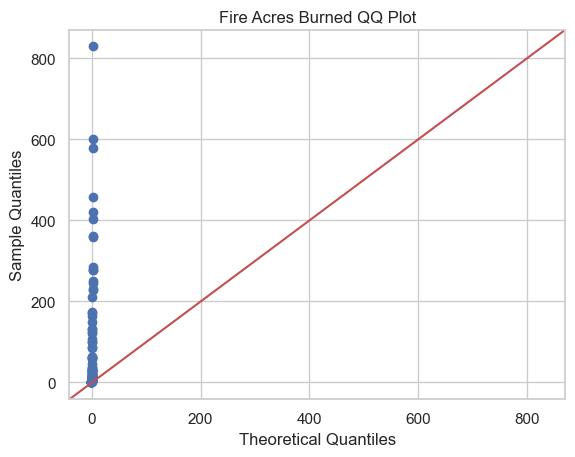

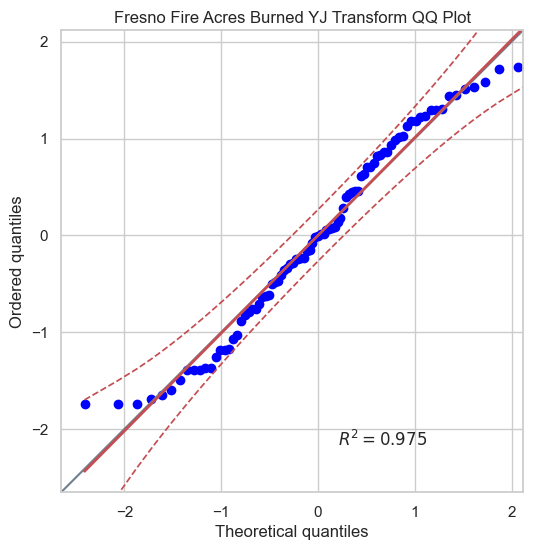

Text(0.5, 1.0, 'Fresno QQ Plot for Yeo-Johnson PESTICIDE_Total ')

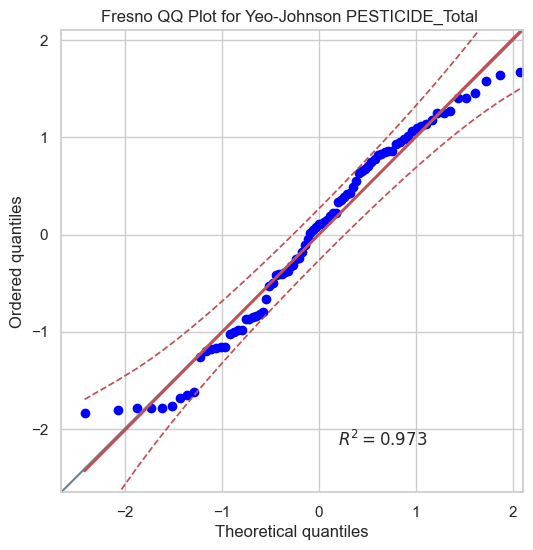

In [97]:
pt = PowerTransformer(method='yeo-johnson', standardize=True)
newdata = pt.fit_transform(df["FIRE_Acres_Burned"].values.reshape(-1,1))

_, pval = shapiro(newdata.flatten())
print(f"fire burn pval {pval}")

plt.figure(figsize=(10,6))
sm.qqplot(df["FIRE_Acres_Burned"], line='45')
plt.title("Fire Acres Burned QQ Plot")

!pip install pingouin
import pingouin as pg

# Flatten your data
data = newdata.flatten()

# This produces the plot with the shaded 95% confidence band automatically
plt.figure(figsize=(10, 6))
pg.qqplot(data, dist='norm', confidence=0.95)

plt.title(f"{county} Fire Acres Burned YJ Transform QQ Plot")
plt.show()

plt.figure(figsize=(10,6))
pg.qqplot(vals.flatten(), dist='norm', confidence=0.95)
plt.title(f"{county} QQ Plot for Yeo-Johnson PESTICIDE_Total ")




It seems that Precipitation will not work will with the `np.log1p` transformation but the other variables seem to be okay. 

Now, the next stage is to create the datasets as CSV files. I will create the following:

- Baseline: typical CSV
- logVFRate: log1p of VFRate
- log1pFeats: CSV with log1p of Fire, Pesticide, Rodenticide
- log1pAll: CSV with log1p of VFRate and features 

In [76]:
'''df_new = df.copy()
print(df_new.head())
df_new.to_csv(f'../../data/{county.lower()}_agg_drought_baseline.csv', index=False)'''

"df_new = df.copy()\nprint(df_new.head())\ndf_new.to_csv(f'../../data/{county.lower()}_agg_drought_baseline.csv', index=False)"

In [77]:
df_vflog = df.copy()
df_vflog["VFRate"] = np.log1p(df["VFRate"])
df_vflog = df_vflog.rename(columns={"VFRate" : "log1pVFRate"})
print(df_vflog.head())
'''df_vflog.to_csv(f'../../data/{county.lower()}_agg_drought_vflog.csv', index=False)'''

  YEAR_MONTH  log1pVFRate  FIRE_Acres_Burned  PRECIP  WIND_EventCount  \
0 2008-10-01     1.968000             163.91    0.18              0.0   
1 2008-11-01     1.483416              17.30    1.49              0.0   
2 2008-12-01     2.013055               0.00    1.19              0.0   
3 2009-01-01     2.030750               1.00    1.25              0.0   
4 2009-02-01     1.909784              28.00    2.33              0.0   

   WIND_AvgMPH  WIND_RunMiles  AQI_PM25  AQI_PM10  EARTHQUAKE_Total  \
0     3.667742      87.825806      70.0      53.0                 0   
1     3.106667      74.490000      95.5      38.5                 0   
2     3.306452      79.312903      94.0      18.5                 0   
3     2.587097      62.019355     102.0      33.0                 0   
4     3.928571      94.096429      51.5      13.0                 0   

   PESTICIDE_Total  RODENTICIDE_Total  Avg_Monthly_DSCI  
0        23.056051           782.3835          515.4225  
1         0.519323

"df_vflog.to_csv(f'../../data/{county.lower()}_agg_drought_vflog.csv', index=False)"

In [78]:
df_featurelog = df.copy()
df_featurelog["FIRE_Acres_Burned"] = np.log1p(df["FIRE_Acres_Burned"])
df_featurelog["PESTICIDE_Total"] = np.log1p(df["PESTICIDE_Total"])
df_featurelog["RODENTICIDE_Total"] = np.log1p(df["RODENTICIDE_Total"])
df_featurelog = df_featurelog.rename(columns={"FIRE_Acres_Burned" : "log1pFire", "PESTICIDE_Total" : "log1pPESTICIDE", "RODENTICIDE_Total" : "log1pRODENTICIDE"})
print(df_featurelog.head())
# df_featurelog.to_csv(f'../../data/{county.lower()}_agg_drought_featlog.csv', index=False)

  YEAR_MONTH    VFRate  log1pFire  PRECIP  WIND_EventCount  WIND_AvgMPH  \
0 2008-10-01  6.156349   5.105400    0.18              0.0     3.667742   
1 2008-11-01  3.407979   2.906901    1.49              0.0     3.106667   
2 2008-12-01  6.486154   0.000000    1.19              0.0     3.306452   
3 2009-01-01  6.619800   0.693147    1.25              0.0     2.587097   
4 2009-02-01  5.751629   3.367296    2.33              0.0     3.928571   

   WIND_RunMiles  AQI_PM25  AQI_PM10  EARTHQUAKE_Total  log1pPESTICIDE  \
0      87.825806      70.0      53.0                 0        3.180387   
1      74.490000      95.5      38.5                 0        0.418265   
2      79.312903      94.0      18.5                 0        0.000000   
3      62.019355     102.0      33.0                 0        3.243779   
4      94.096429      51.5      13.0                 0        4.284178   

   log1pRODENTICIDE  Avg_Monthly_DSCI  
0          6.663622          515.4225  
1          6.247420     

In [79]:
df_vfandfeatlog = df.copy()
df_vfandfeatlog["VFRate"] = np.log1p(df["VFRate"])
df_vfandfeatlog["FIRE_Acres_Burned"] = np.log1p(df["FIRE_Acres_Burned"])
df_vfandfeatlog["PESTICIDE_Total"] = np.log1p(df["PESTICIDE_Total"])
df_vfandfeatlog["RODENTICIDE_Total"] = np.log1p(df["RODENTICIDE_Total"])
df_vfandfeatlog = df_vfandfeatlog.rename(columns={"VFRate" : "log1pVFRate", "FIRE_Acres_Burned" : "log1pFire", "PESTICIDE_Total" : "log1pPESTICIDE", "RODENTICIDE_Total" : "log1pRODENTICIDE"})
print(df_vfandfeatlog.head())
# df_vfandfeatlog.to_csv(f'../../data/{county.lower()}_agg_drought_vfandfeatlog.csv', index=False)'''

  YEAR_MONTH  log1pVFRate  log1pFire  PRECIP  WIND_EventCount  WIND_AvgMPH  \
0 2008-10-01     1.968000   5.105400    0.18              0.0     3.667742   
1 2008-11-01     1.483416   2.906901    1.49              0.0     3.106667   
2 2008-12-01     2.013055   0.000000    1.19              0.0     3.306452   
3 2009-01-01     2.030750   0.693147    1.25              0.0     2.587097   
4 2009-02-01     1.909784   3.367296    2.33              0.0     3.928571   

   WIND_RunMiles  AQI_PM25  AQI_PM10  EARTHQUAKE_Total  log1pPESTICIDE  \
0      87.825806      70.0      53.0                 0        3.180387   
1      74.490000      95.5      38.5                 0        0.418265   
2      79.312903      94.0      18.5                 0        0.000000   
3      62.019355     102.0      33.0                 0        3.243779   
4      94.096429      51.5      13.0                 0        4.284178   

   log1pRODENTICIDE  Avg_Monthly_DSCI  
0          6.663622          515.4225  
1     